In [1]:
import pandas as pd
import sqlite3 
from pandas.plotting import scatter_matrix
import matplotlib.pyplot as plt

In [2]:
conn = sqlite3.connect('../data/checking-logs.sqlite')

In [3]:
commits_query = """
SELECT uid, COUNT(*) as num_commits
FROM checker
WHERE labname != 'project1'
GROUP BY uid
"""
commits_df = pd.read_sql_query(commits_query, conn)
commits_df.head()


,uid,num_commits
0,None,4
1,admin_1,7
2,admin_2,1
3,user_0,3
4,user_1,62


In [4]:
pageviews_query = """
SELECT uid, COUNT(*) as pageviews
FROM pageviews
GROUP BY uid
"""
pageviews_df = pd.read_sql_query(pageviews_query, conn)
commits_df.head()

,uid,num_commits
0,None,4
1,admin_1,7
2,admin_2,1
3,user_0,3
4,user_1,62


In [5]:
df_csv = pd.read_csv('../data/ab-test.csv')
test_users_from_csv = df_csv[df_csv['group'] == 'test']['uid'].unique()
test_users_df = pd.DataFrame({'uid': test_users_from_csv})

In [6]:
test_users_query = """
SELECT DISTINCT uid
FROM test
"""
test_users = pd.read_sql_query(test_users_query, conn)
test_users.head()

,uid
0,user_1
1,user_10
2,user_14
3,user_17
4,user_18


In [7]:
diff_query = """
SELECT test.uid, AVG((strftime("%s", first_commit_ts) - deadlines.deadlines)/3600) AS avg_diff
FROM
    deadlines
    INNER JOIN test ON labname = labs AND labname != "project1"
GROUP BY test.uid
"""
avg_diff_df = pd.read_sql_query(diff_query, conn)

In [8]:
df_test = pd.merge(test_users, commits_df, on='uid', how='left')
df_test = pd.merge(df_test, pageviews_df, on='uid', how='left')
df_test = pd.merge(df_test, avg_diff_df, on='uid', how='left')
df_test = df_test.drop_duplicates(subset=['uid'])
df_test.head(10)

,uid,num_commits,pageviews,avg_diff
0,user_1,62,28,-64.400000
1,user_10,20,89,-74.800000
2,user_14,61,143,-159.000000
3,user_17,51,47,-61.600000
4,user_18,5,3,-5.666667
5,user_19,118,16,-98.750000
6,user_21,65,10,-95.500000
7,user_25,79,179,-92.600000
8,user_28,60,149,-86.400000
9,user_3,18,317,-105.400000


array([[<Axes: xlabel='avg_diff', ylabel='avg_diff'>,
        <Axes: xlabel='pageviews', ylabel='avg_diff'>,
        <Axes: xlabel='num_commits', ylabel='avg_diff'>],
       [<Axes: xlabel='avg_diff', ylabel='pageviews'>,
        <Axes: xlabel='pageviews', ylabel='pageviews'>,
        <Axes: xlabel='num_commits', ylabel='pageviews'>],
       [<Axes: xlabel='avg_diff', ylabel='num_commits'>,
        <Axes: xlabel='pageviews', ylabel='num_commits'>,
        <Axes: xlabel='num_commits', ylabel='num_commits'>]], dtype=object)

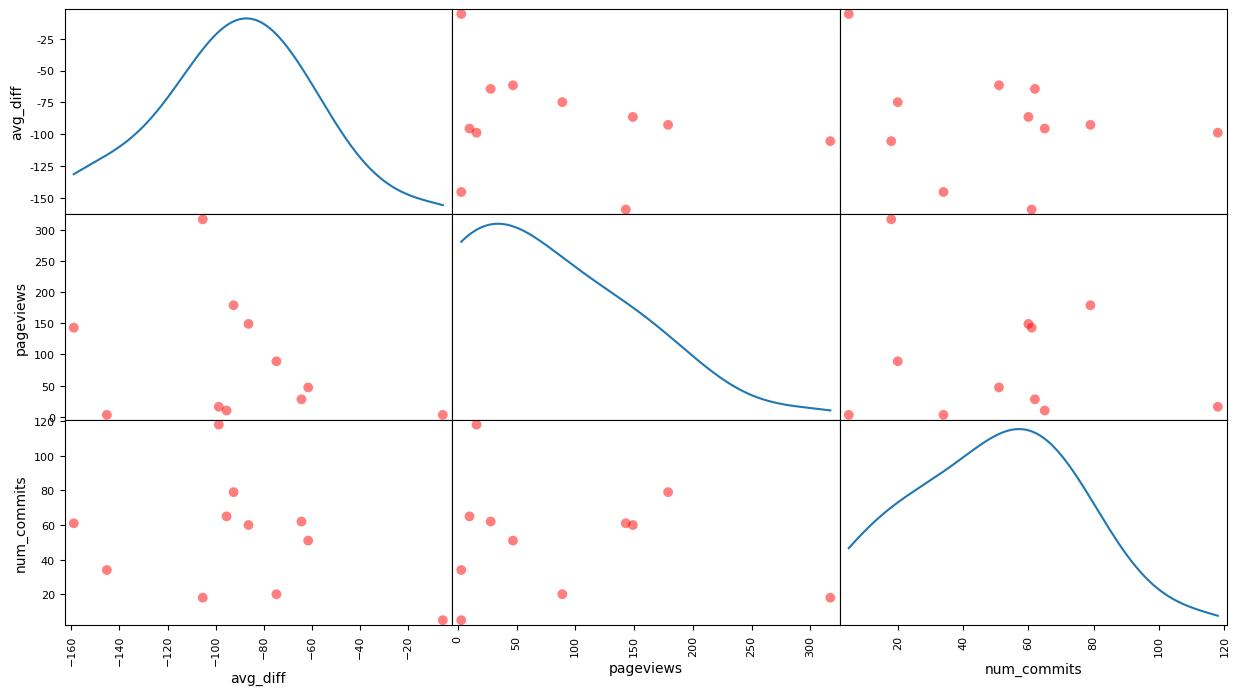

In [9]:
scatter_matrix(
    df_test[['avg_diff', 'pageviews', 'num_commits']],
    figsize=(15,8),
    color='red',
    diagonal='kde',
    s=200,
    hist_kwds={'linewidth': 3}
)


 
 **1. Можем ли мы сказать, что если у пользователя мало просмотров страниц, то у него, вероятно, мало коммитов?**
 
 **ДА**
 
 **2. Можем ли мы сказать, что если у пользователя небольшое количество просмотров страниц, то у него, вероятно, небольшая средняя разница между первой фиксацией и крайним сроком лабораторной работы?**
 
 **НЕТ**
 
 **3. Можем ли мы сказать, что есть много пользователей с низким количеством коммитов и несколько с большим количеством коммитов?**
 
 **ДА**
 
 **4. Можем ли мы сказать, что есть много пользователей с небольшой средней разницей и несколько с большой средней разницей?**
 
 **ДА**